In [99]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## Get loftee_hc significant appv correlations

In [2]:
# Configuration and paths
corr_method = 'pearson'
trait_type = 'quantitative'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac


759.292

In [ ]:
appv = pl.read_parquet("/home/dnanexus/data_dir/avg_pheno_per_var_quantitative_EUR_genebass1e6coding_PRScorr.parquet")
appv = appv.filter(pl.col('n_individuals')<=mac)
appv

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value
str,str,u32,f32,f32
"""chr1:3476029:G:A""","""red_blood_cell_erythrocyte_dis…",19,-0.347493,0.960577
"""chr1:2229460:C:T""","""red_blood_cell_erythrocyte_dis…",1,0.426851,null
"""chr1:10072146:G:A""","""red_blood_cell_erythrocyte_dis…",22,-0.12495,0.843646
"""chr1:3463318:G:A""","""mean_platelet_thrombocyte_volu…",128,-0.015066,0.846027
"""chr1:2515618:C:T""","""mean_platelet_thrombocyte_volu…",98,0.011947,0.797165
…,…,…,…,…
"""chr22:50454662:G:A""","""microalbumin_in_urine_int""",1,-0.803816,null
"""chr22:50455057:C:G""","""mothers_age_at_death_int""",1,1.928162,null
"""chr22:50283981:T:C""","""mothers_age_at_death_int""",1,1.303833,null


In [4]:
alof = pl.read_parquet("/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag/annotations.parquet", columns=['id', 'region', 'loftee_hc'])
alof

id,region,loftee_hc
str,str,i8
"""chr1:169795116:G:C""","""ENSG00000000460""",0
"""chr1:169798959:G:A""","""ENSG00000000460""",0
"""chr1:169798959:G:C""","""ENSG00000000460""",0
"""chr1:169798959:G:GT""","""ENSG00000000460""",0
"""chr1:169798959:G:T""","""ENSG00000000460""",0
…,…,…
"""chr7:151061966:C:T""","""ENSG00000288608""",0
"""chr7:151061967:GA:G""","""ENSG00000288608""",1
"""chr7:151061968:A:G""","""ENSG00000288608""",0


In [5]:
alof['region'].value_counts(sort=True)

region,count
str,u64
"""ENSG00000143631""",9263
"""ENSG00000008710""",8573
"""ENSG00000081853""",8384
"""ENSG00000178209""",8265
"""ENSG00000151914""",7460
…,…
"""ENSG00000072694""",73
"""ENSG00000164032""",67
"""ENSG00000162188""",59


In [6]:
gnames = pl.read_csv('/home/dnanexus/data_dir/gnomad.v4.1.constraint_metrics.tsv',
    separator='\t',
    null_values=['.', 'NA'],
).filter(
    pl.col('transcript_type') == 'protein_coding'
).select(['gene', 'gene_id']).unique().rename({
    'gene': 'gene_name',
    'gene_id': 'region'
}).drop_nulls()

gnames

gene_name,region
str,str
"""SLC7A4""","""ENSG00000099960"""
"""WNT7A""","""ENSG00000154764"""
"""MACROD1""","""ENSG00000133315"""
"""NOTCH1""","""ENSG00000148400"""
"""ZNF77""","""ENSG00000175691"""
…,…
"""SPATA31A1""","""ENSG00000204849"""
"""LGR4""","""ENSG00000205213"""
"""PIN1""","""ENSG00000127445"""


In [7]:
alof_gp = appv.join(alof, on='id', how='inner').join(gnames, on='region', how='left')
alof_gp

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value,region,loftee_hc,gene_name
str,str,u32,f32,f32,str,i8,str
"""chr1:3476029:G:A""","""red_blood_cell_erythrocyte_dis…",19,-0.347493,0.960577,"""ENSG00000130762""",0,"""ARHGEF16"""
"""chr1:2229460:C:T""","""red_blood_cell_erythrocyte_dis…",1,0.426851,null,"""ENSG00000157933""",0,"""SKI"""
"""chr1:10072146:G:A""","""red_blood_cell_erythrocyte_dis…",22,-0.12495,0.843646,"""ENSG00000130939""",0,"""UBE4B"""
"""chr1:3463318:G:A""","""mean_platelet_thrombocyte_volu…",128,-0.015066,0.846027,"""ENSG00000130762""",0,"""ARHGEF16"""
"""chr1:2515618:C:T""","""mean_platelet_thrombocyte_volu…",98,0.011947,0.797165,"""ENSG00000157881""",0,"""PANK4"""
…,…,…,…,…,…,…,…
"""chr22:50454662:G:A""","""microalbumin_in_urine_int""",1,-0.803816,null,"""ENSG00000100241""",0,"""SBF1"""
"""chr22:50455057:C:G""","""mothers_age_at_death_int""",1,1.928162,null,"""ENSG00000100241""",0,"""SBF1"""
"""chr22:50283981:T:C""","""mothers_age_at_death_int""",1,1.303833,null,"""ENSG00000196576""",0,"""PLXNB2"""


In [39]:
# 1. Aggregate to get correlation (r) and number of pairs (n)
lofcorr_df = (
    alof_gp.lazy()
    .group_by(["region", "gene_name", "phenotype"])
    .agg(
        pl.col("id").count().alias("n_variants"),
        pl.col("loftee_hc").sum().alias("n_plof"),
        # Add this line to count the number of non-null pairs used for the correlation, same as n_variants
        (pl.col("mean_pheno_value").is_not_null() & pl.col("loftee_hc").is_not_null()).sum().alias("n_variants_nonull"),
        pl.corr("mean_pheno_value", "loftee_hc").alias("correlation"),
    )
    .filter(
        (pl.col("n_variants_nonull") > 2) &
        (pl.col("n_plof") > 0)
    )  
    
    # 2. Compute the t-statistic and p-value on the aggregated results
    .with_columns(
        # Calculate the t-statistic from r and n
        t_stat=pl.col("correlation") * ((pl.col("n_variants_nonull") - 2) / (1 - pl.col("correlation")**2))**0.5,
    )
    .with_columns(
        # Calculate the two-tailed p-value from the t-statistic
        p_value=pl.struct(["t_stat", "n_variants_nonull"]).map_elements(
            lambda x: (
                stats.t.sf(np.abs(x["t_stat"]), df=x["n_variants_nonull"] - 2) * 2
                if x["t_stat"] is not None else None
            ),
            return_dtype=pl.Float64
        )
    )
).collect(engine='streaming')

lofcorr_df

region,gene_name,phenotype,n_variants,n_plof,n_variants_nonull,correlation,t_stat,p_value
str,str,str,u64,i64,u64,f32,f64,f64
"""ENSG00000185666""","""SYN3""","""creatinine_enzymatic_in_urine_…",568,32,568,0.040618,0.96712,0.333897
"""ENSG00000012048""","""BRCA1""","""trunk_fatfree_mass_int""",1168,138,1168,0.029938,1.022758,0.306635
"""ENSG00000064932""","""SBNO2""","""sitting_height_int""",1771,85,1771,0.05198,2.189204,0.028712
"""ENSG00000105376""","""ICAM5""","""weight_int""",744,30,744,-0.037066,-1.010368,0.312648
"""ENSG00000120438""","""TCP1""","""phosphate_int""",520,6,520,0.023421,0.533202,0.594122
…,…,…,…,…,…,…,…,…
"""ENSG00000160229""","""ZNF66""","""platelet_distribution_width_in…",155,23,155,0.088526,1.099322,0.273354
"""ENSG00000173542""","""MOB1B""","""red_blood_cell_erythrocyte_cou…",146,10,146,0.151335,1.837177,0.068245
"""ENSG00000048405""","""ZNF800""","""basophill_count_int""",362,9,362,0.034539,0.655719,0.512424


In [44]:
lofcorr_df.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name)
)

region,gene_name,phenotype,n_variants,n_plof,n_variants_nonull,correlation,t_stat,p_value
str,str,str,u64,i64,u64,f32,f64,f64
"""ENSG00000169047""","""IRS1""","""basal_metabolic_rate_int""",1053,57,1053,-0.149431,-4.899424,0.000001


In [45]:
lofcorr_df.filter(pl.col('p_value') < 0.05/gnames['region'].n_unique())

region,gene_name,phenotype,n_variants,n_plof,n_variants_nonull,correlation,t_stat,p_value
str,str,str,u64,i64,u64,f32,f64,f64
"""ENSG00000162733""","""DDR2""","""leg_fatfree_mass_left_int""",511,19,511,-0.221506,-5.124695,4.2389e-7
"""ENSG00000173064""","""HECTD4""","""leg_fat_percentage_left_int""",2693,79,2693,0.114921,6.00125,2.2210e-9
"""ENSG00000164061""","""BSN""","""arm_fat_percentage_right_int""",3229,61,3229,0.084416,4.81255,0.000002
"""ENSG00000146112""","""PPP1R18""","""body_mass_index_bmi_impedance_…",525,33,525,0.214551,5.023592,6.9713e-7
"""ENSG00000187045""","""TMPRSS6""","""haemoglobin_concentration_int""",710,56,710,-0.202709,-5.508101,5.0794e-8
…,…,…,…,…,…,…,…,…
"""ENSG00000171587""","""DSCAM""","""creactive_protein_int""",1379,41,1379,0.138641,5.194841,2.3570e-7
"""ENSG00000128849""","""CGNL1""","""gamma_glutamyltransferase_int""",1034,79,1034,0.160893,5.23686,1.9790e-7
"""ENSG00000056586""","""RC3H2""","""fluid_intelligence_score_int""",429,13,429,-0.288486,-6.225976,1.1455e-9


In [69]:
from statsmodels.stats.multitest import multipletests

# The helper function to correct p-values
def apply_correction(pvals: pl.Series, method: str) -> pl.Series:
    if pvals.is_empty():
        return pvals
        
    _, pvals_corrected, _, _ = multipletests(
        pvals=pvals.to_numpy(),
        alpha=0.05,
        method=method
    )
    
    result = pl.Series(name=pvals.name, values=pvals_corrected, dtype=pl.Float64)
    return result

# Apply the correction using .map_batches() and .alias()
final_df = lofcorr_df.with_columns(
    pl.col("p_value").map_batches(
        lambda series: apply_correction(series, method='bonferroni'),
        return_dtype=pl.Float64  # Tell Polars the output type
    ).over("phenotype").alias("p_adj_bonf"),

    pl.col("p_value").map_batches(
        lambda series: apply_correction(series, method='holm'),
        return_dtype=pl.Float64  # Tell Polars the output type
    ).over("phenotype").alias("p_adj_holm"),
    
    pl.col("p_value").map_batches(
        lambda series: apply_correction(series, method='fdr_bh'),
        return_dtype=pl.Float64  # Tell Polars the output type
    ).over("phenotype").alias("p_adj_bh")
)
# View the final results
final_df

region,gene_name,phenotype,n_variants,n_plof,n_variants_nonull,correlation,t_stat,p_value,p_adj_bonf,p_adj_holm,p_adj_bh
str,str,str,u64,i64,u64,f32,f64,f64,f64,f64,f64
"""ENSG00000185666""","""SYN3""","""creatinine_enzymatic_in_urine_…",568,32,568,0.040618,0.96712,0.333897,1.0,1.0,0.867708
"""ENSG00000012048""","""BRCA1""","""trunk_fatfree_mass_int""",1168,138,1168,0.029938,1.022758,0.306635,1.0,1.0,0.761657
"""ENSG00000064932""","""SBNO2""","""sitting_height_int""",1771,85,1771,0.05198,2.189204,0.028712,1.0,1.0,0.243892
"""ENSG00000105376""","""ICAM5""","""weight_int""",744,30,744,-0.037066,-1.010368,0.312648,1.0,1.0,0.762672
"""ENSG00000120438""","""TCP1""","""phosphate_int""",520,6,520,0.023421,0.533202,0.594122,1.0,1.0,0.916349
…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000160229""","""ZNF66""","""platelet_distribution_width_in…",155,23,155,0.088526,1.099322,0.273354,1.0,1.0,0.765086
"""ENSG00000173542""","""MOB1B""","""red_blood_cell_erythrocyte_cou…",146,10,146,0.151335,1.837177,0.068245,1.0,1.0,0.54077
"""ENSG00000048405""","""ZNF800""","""basophill_count_int""",362,9,362,0.034539,0.655719,0.512424,1.0,1.0,0.884604


## Comparing to pLoF burden test

In [74]:
corr_signif = final_df.filter(pl.col('p_adj_bh') < 0.05)
corr_signif

region,gene_name,phenotype,n_variants,n_plof,n_variants_nonull,correlation,t_stat,p_value,p_adj_bonf,p_adj_holm,p_adj_bh
str,str,str,u64,i64,u64,f32,f64,f64,f64,f64,f64
"""ENSG00000112077""","""RHAG""","""hand_grip_strength_right_int""",321,17,321,-0.206044,-3.760766,0.000201,0.405182,0.399944,0.015007
"""ENSG00000004939""","""SLC4A1""","""cystatin_c_int""",663,22,663,0.166264,4.334963,0.000017,0.033869,0.033667,0.002421
"""ENSG00000084774""","""CAD""","""reticulocyte_count_int""",1603,80,1603,-0.094003,-3.778027,0.000164,0.32904,0.326582,0.020565
"""ENSG00000196712""","""NF1""","""hand_grip_strength_left_int""",1630,131,1630,-0.081076,-3.282108,0.001052,1.0,1.0,0.044513
"""ENSG00000283632""","""EXOC3L2""","""mean_corpuscular_haemoglobin_i…",768,30,768,0.124156,3.463023,0.000564,1.0,1.0,0.030613
…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000118007""","""STAG1""","""creatinine_enzymatic_in_urine_…",631,7,631,0.173503,4.418443,0.000012,0.023542,0.02353,0.011771
"""ENSG00000177853""","""ZNF518A""","""standing_height_int""",1168,58,1168,0.103586,3.556266,0.000391,0.786797,0.75941,0.01095
"""ENSG00000132507""","""EIF5A""","""weight_impedance_int""",164,3,164,-0.25413,-3.344345,0.001025,1.0,1.0,0.043846


In [ ]:
gb = pl.read_parquet('/home/dnanexus/data_dir/genebass_continuous_associations_ukbbgym.pq').with_columns(
    (pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.to_lowercase() + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region'),
    pl.col('gene_symbol').alias('gene_name')
).filter(
    (pl.col('annotation') == 'pLoF')
    # (pl.col('annotation').str.contains('pLoF'))
)

gene_trait_df = gb[['region', 'gene_id', 'gene_name', 'phenotype', 'trait_type']].unique()
gene_trait_df

region,gene_id,gene_name,phenotype,trait_type
str,str,str,str,str
"""ENSG00000152270""","""ENSG00000152270""","""PDE3B""","""basal_metabolic_rate_int""","""continuous"""
"""ENSG00000131183""","""ENSG00000131183""","""SLC34A1""","""cystatin_c_int""","""continuous"""
"""ENSG00000283683""","""ENSG00000283683""","""MYOCOS""","""recent_changes_in_speed/amount…","""continuous"""
"""ENSG00000151914""","""ENSG00000151914""","""DST""","""forced_expiratory_volume_in_1-…","""continuous"""
"""ENSG00000110697""","""ENSG00000110697""","""PITPNM1""","""frequency_of_failure_to_fulfil…","""continuous"""
…,…,…,…,…
"""ENSG00000196544""","""ENSG00000196544""","""BORCS6""","""frequency_of_memory_loss_due_t…","""continuous"""
"""ENSG00000160714""","""ENSG00000160714""","""UBE2Q1""","""frequency_of_memory_loss_due_t…","""continuous"""
"""ENSG00000198398""","""ENSG00000198398""","""TMEM207""","""recent_changes_in_speed/amount…","""continuous"""


In [87]:
plof = pl.read_parquet('/home/dnanexus/data_dir/rvat_EUR_500k_regenie.parquet').with_columns(
    (pl.col('trait') + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region')
).filter(
    (pl.col('trait_type') == 'quantitative')
)

plof = plof.with_columns(
    (10** -pl.col("neg_log10p")).alias("p_value")
).with_columns(
    pl.col("p_value").map_batches(
        lambda series: apply_correction(series, method='bonferroni'),
        return_dtype=pl.Float64  # Tell Polars the output type
    ).over("phenotype").alias("p_adj_bonf"),

    pl.col("p_value").map_batches(
        lambda series: apply_correction(series, method='holm'),
        return_dtype=pl.Float64  # Tell Polars the output type
    ).over("phenotype").alias("p_adj_holm"),
    
    pl.col("p_value").map_batches(
        lambda series: apply_correction(series, method='fdr_bh'),
        return_dtype=pl.Float64  # Tell Polars the output type
    ).over("phenotype").alias("p_adj_bh")
)

plof_signif = plof.filter(pl.col('p_adj_bh') < 0.05)
plof_signif

gene_name,chrom,gene_id,plof_freq,n_samples,beta,se,chisq,neg_log10p,trait,trait_type,nom_significance,n_genes,bonf_significance,phenotype,region,p_value,p_adj_bonf,p_adj_holm,p_adj_bh
str,i64,str,f64,i64,f64,f64,f64,f64,str,str,bool,u64,bool,str,str,f64,f64,f64,f64
"""TMEM240""",1,"""ENSG00000205090""",0.000008,357443,-0.891793,0.232211,14.749,3.91076,"""arm_fatfree_mass_right""","""quantitative""",true,17356,false,"""arm_fatfree_mass_right_int""","""ENSG00000205090""",0.000123,1.0,1.0,0.044996
"""TRNAU1AP""",1,"""ENSG00000180098""",0.000141,357443,0.217876,0.056606,14.8148,3.9259,"""arm_fatfree_mass_right""","""quantitative""",true,17356,false,"""arm_fatfree_mass_right_int""","""ENSG00000180098""",0.000119,1.0,1.0,0.04475
"""RPF1""",1,"""ENSG00000117133""",0.000373,357443,0.134444,0.0348228,14.9058,3.94687,"""arm_fatfree_mass_right""","""quantitative""",true,17356,false,"""arm_fatfree_mass_right_int""","""ENSG00000117133""",0.000113,1.0,1.0,0.044579
"""PAPPA2""",1,"""ENSG00000116183""",0.000339,357443,-0.195409,0.0365758,28.5431,7.03793,"""arm_fatfree_mass_right""","""quantitative""",true,17356,true,"""arm_fatfree_mass_right_int""","""ENSG00000116183""",9.1637e-8,0.00159,0.00159,0.000181
"""DTL""",1,"""ENSG00000143476""",0.000152,357443,-0.232484,0.0544889,18.2042,4.70236,"""arm_fatfree_mass_right""","""quantitative""",true,17356,false,"""arm_fatfree_mass_right_int""","""ENSG00000143476""",0.00002,0.344421,0.343865,0.011877
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""VPS13A""",9,"""ENSG00000197969""",0.001064,347730,0.176348,0.0339876,26.9216,6.67392,"""reticulocyte_count""","""quantitative""",true,17340,true,"""reticulocyte_count_int""","""ENSG00000197969""",2.1188e-7,0.003674,0.003671,0.000245
"""LRP5""",11,"""ENSG00000162337""",0.000231,114532,-0.794196,0.128014,38.4893,9.2592,"""heel_bone_mineral_density_bmd_…","""quantitative""",true,16041,true,"""heel_bone_mineral_density_bmd_…","""ENSG00000162337""",5.5055e-10,0.000009,0.000009,0.000004
"""CD63""",12,"""ENSG00000135404""",0.000266,114532,0.562505,0.119009,22.3405,5.64142,"""heel_bone_mineral_density_bmd_…","""quantitative""",true,16041,true,"""heel_bone_mineral_density_bmd_…","""ENSG00000135404""",0.000002,0.036628,0.036623,0.012209


In [88]:
# Compare gene-phenotype associations between gene_trait_df and corr_signif

# unique pairs in each table
gt_pairs = plof_signif.select(['gene_name', 'phenotype']).unique()
cs_pairs = corr_signif.select(['gene_name', 'phenotype']).unique()

# pairs present in gene_trait_df but missing in corr_signif
in_gt_not_cs = gt_pairs.join(cs_pairs, on=['gene_name', 'phenotype'], how='anti')

# pairs present in corr_signif but missing in gene_trait_df
in_cs_not_gt = cs_pairs.join(gt_pairs, on=['gene_name', 'phenotype'], how='anti')

# pairs present in both
in_both = gt_pairs.join(cs_pairs, on=['gene_name', 'phenotype'], how='inner')

# summary counts
print(f"unique pairs in gene_trait_df: {gt_pairs.shape[0]}")
print(f"unique pairs in corr_signif:   {cs_pairs.shape[0]}")
print(f"in gene_trait_df but not corr_signif: {in_gt_not_cs.shape[0]}")
print(f"in corr_signif but not gene_trait_df: {in_cs_not_gt.shape[0]}")
print(f"in both: {in_both.shape[0]}")

unique pairs in gene_trait_df: 2668
unique pairs in corr_signif:   3174
in gene_trait_df but not corr_signif: 1792
in corr_signif but not gene_trait_df: 2298
in both: 876


In [89]:
# show top 10 most significant pairs (by p-value) for each set
top_in_gt_not_cs = (
    in_gt_not_cs.join(
        plof_signif.select(['gene_name', 'phenotype', 'p_value']),
        on=['gene_name', 'phenotype'],
        how='left'
    )
    .sort('p_value', nulls_last=True)
    .head(10)
)
print("\nTop (gene_trait_df \\ corr_signif) sorted by p-value:")
print(top_in_gt_not_cs)

top_in_cs_not_gt = (
    in_cs_not_gt.join(
        final_df.select(['gene_name', 'phenotype', 'p_value']),
        on=['gene_name', 'phenotype'],
        how='left'
    )
    .sort('p_value', nulls_last=True)
    .head(10)
)
print("\nTop (corr_signif \\ gene_trait_df) sorted by p-value:")
print(top_in_cs_not_gt)


Top (gene_trait_df \ corr_signif) sorted by p-value:
shape: (10, 3)
┌───────────┬─────────────────────────────────┬─────────────┐
│ gene_name ┆ phenotype                       ┆ p_value     │
│ ---       ┆ ---                             ┆ ---         │
│ str       ┆ str                             ┆ f64         │
╞═══════════╪═════════════════════════════════╪═════════════╡
│ GP1BA     ┆ mean_platelet_thrombocyte_volu… ┆ 1.3183e-102 │
│ APOC3     ┆ triglycerides_int               ┆ 1.4441e-72  │
│ ANGPTL3   ┆ apolipoprotein_a_int            ┆ 2.3933e-56  │
│ GP1BB     ┆ mean_platelet_thrombocyte_volu… ┆ 4.4494e-55  │
│ IGFALS    ┆ igf1_int                        ┆ 9.4755e-52  │
│ ANGPTL3   ┆ cholesterol_int                 ┆ 2.2289e-49  │
│ RHAG      ┆ glycated_haemoglobin_hba1c_int  ┆ 1.0745e-45  │
│ RHAG      ┆ reticulocyte_percentage_int     ┆ 4.1581e-44  │
│ ASXL1     ┆ platelet_distribution_width_in… ┆ 6.7422e-44  │
│ LCORL     ┆ standing_height_int             ┆ 8.9023e-44  │
└

In [90]:
# If you want to inspect which genes contribute most to the differences:
print("\nTop genes with most pairs in gene_trait_df but missing in corr_signif:")
print(
    in_gt_not_cs.lazy()
    .group_by("gene_name")
    .agg(pl.count().alias("n_missing"))
    .sort("n_missing", descending=True)
    .head(10)
    .collect()
)

print("\nTop genes with most pairs in corr_signif but missing in gene_trait_df:")
print(
    in_cs_not_gt.lazy()
    .group_by("gene_name")
    .agg(pl.count().alias("n_missing"))
    .sort("n_missing", descending=True)
    .head(10)
    .collect()
)


Top genes with most pairs in gene_trait_df but missing in corr_signif:
shape: (10, 2)
┌───────────┬───────────┐
│ gene_name ┆ n_missing │
│ ---       ┆ ---       │
│ str       ┆ u64       │
╞═══════════╪═══════════╡
│ PDE3B     ┆ 46        │
│ G6PC1     ┆ 28        │
│ TTN       ┆ 26        │
│ LCORL     ┆ 24        │
│ BLTP1     ┆ 21        │
│ PTPRJ     ┆ 21        │
│ ASXL1     ┆ 20        │
│ GHRH      ┆ 18        │
│ SLTM      ┆ 15        │
│ CNPY2     ┆ 15        │
└───────────┴───────────┘

Top genes with most pairs in corr_signif but missing in gene_trait_df:
shape: (10, 2)
┌───────────┬───────────┐
│ gene_name ┆ n_missing │
│ ---       ┆ ---       │
│ str       ┆ u64       │
╞═══════════╪═══════════╡
│ PKD1      ┆ 35        │
│ C1QL4     ┆ 35        │
│ HECTD4    ┆ 31        │
│ DOT1L     ┆ 29        │
│ FRYL      ┆ 28        │
│ COL1A1    ┆ 27        │
│ TUT7      ┆ 27        │
│ USP47     ┆ 27        │
│ ARHGAP21  ┆ 26        │
│ UHRF1     ┆ 24        │
└───────────┴───────

/tmp/ipykernel_390194/3538324539.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
/tmp/ipykernel_390194/3538324539.py:16: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)


## Single gene plots

### Single gene plot from appv

Pearson r: -0.13924303650856018, p-value: 0.014297775616975488


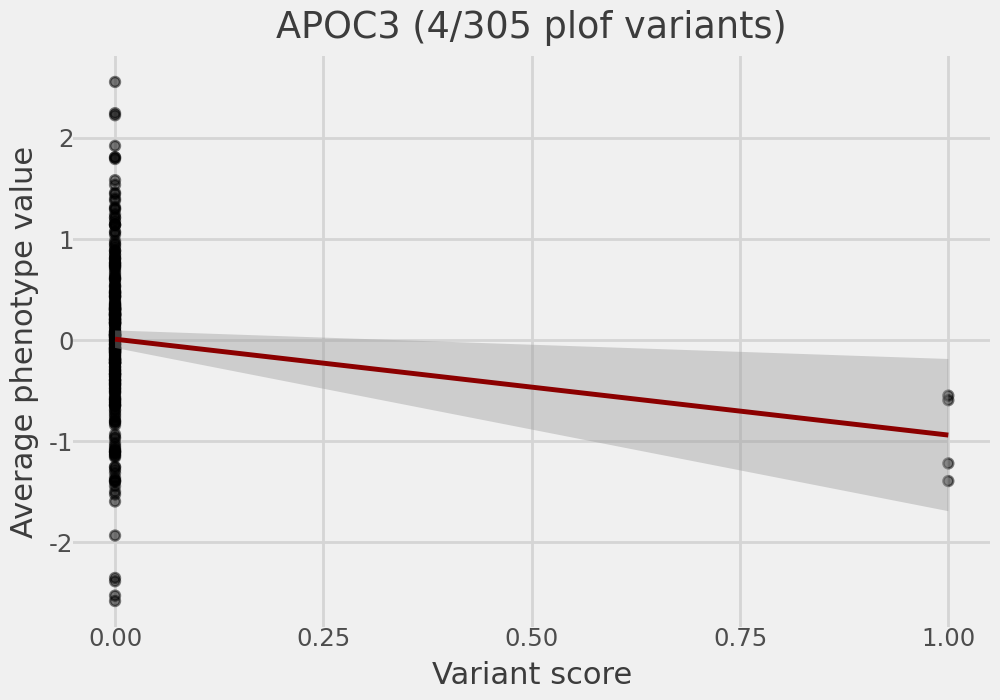

In [109]:
from scipy import stats

method = 'pearson'
# gene_name = 'GCK'
# phenotype = 'glycated_haemoglobin_hba1c_int'
gene_name = "APOC3"
phenotype = "triglycerides_int"

# Filter your main dataframe
sc_df = alof_gp.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name)
).drop_nulls(subset=['loftee_hc', 'mean_pheno_value'])

lof0 = sc_df.filter(pl.col('loftee_hc') == 0).shape[0]
lof1 = sc_df.filter(pl.col('loftee_hc') == 1).shape[0]

# Check if enough data remains for calculation
if len(sc_df) >= 2:
    pearson_r, pearson_p = stats.pearsonr(
        sc_df['loftee_hc'], 
        sc_df['mean_pheno_value']
    )
else:
    pearson_r, pearson_p = np.nan, np.nan

print(f"Pearson r: {pearson_r}, p-value: {pearson_p}")
# Scatter plot
(
    ggplot(sc_df, aes(x='loftee_hc', y='mean_pheno_value')) +
    geom_point(alpha=0.5) +
    geom_smooth(method='lm', se=True, color='darkred') +
    # theme_minimal() +
    theme_538() +
    labs(
        x='Variant score',
        y="Average phenotype value",
        title=f"{gene_name} ({lof1}/{lof0} plof variants)"
    ) +
    theme(figure_size=(5, 3.5))
)

In [110]:
sc_df.filter(pl.col('loftee_hc') > 0)

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value,region,loftee_hc,gene_name
str,str,u32,f32,f32,str,i8,str
"""chr11:116830637:C:T""","""triglycerides_int""",128,-1.21878,0.749998,"""ENSG00000110245""",1,"""APOC3"""
"""chr11:116830616:C:CT""","""triglycerides_int""",5,-1.393228,0.871741,"""ENSG00000110245""",1,"""APOC3"""
"""chr11:116830638:G:T""","""triglycerides_int""",13,-0.593545,1.072028,"""ENSG00000110245""",1,"""APOC3"""
"""chr11:116830771:A:G""","""triglycerides_int""",1,-0.548126,null,"""ENSG00000110245""",1,"""APOC3"""


### Single gene plot from burdens

In [114]:
from anngeno import AnnGeno

ag = AnnGeno('/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag', low_mem=True)
ag

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.


In [115]:
gene_id = sc_df['region'].unique().item()
gdata = ag.get_many_regions([gene_id])[gene_id]
gdata

{'genotypes': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(472, 490541), dtype=int8),
 'variant_ids': array(['chr11:116829905:GTCTGCTCAGTTCATCCCTAGAGGCAGCTGCTCCAGGT:G',
        'chr11:116830568:A:G', 'chr11:116830583:A:T',
        'chr11:116830584:T:C', 'chr11:116830584:T:G',
        'chr11:116830589:C:T', 'chr11:116830591:C:G',
        'chr11:116830592:C:T', 'chr11:116830593:G:A',
        'chr11:116830594:G:A', 'chr11:116830594:G:C',
        'chr11:116830598:C:T', 'chr11:116830601:CTTG:C',
        'chr11:116830604:G:A', 'chr11:116830605:T:C',
        'chr11:116830608:T:G', 'chr11:116830610:G:A',
        'chr11:116830610:G:T', 'chr11:116830611:C:T',
        'chr11:116830612:C:T', 'chr11:116830612:CCTCCTGGCG:C',
        'chr11:116830613:C:T', 'chr11:116830616:C:CT',
        'chr11:116830620:C:A', 'chr11:116830620:C:T

In [124]:
plof_burdens = pl.DataFrame({
    'IID': ag.samples,
    'burden': gdata['genotypes'].T @ gdata['annotations']['loftee_hc'].to_numpy()
})

plof_burdens

IID,burden
str,i8
"""W000001""",0
"""W000002""",0
"""W000003""",0
"""W000004""",0
"""W000005""",0
…,…
"""3923515""",0
"""1108777""",0
"""3548117""",0


In [139]:
config_path = f'/home/dnanexus/ukbgym/config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)
cov_list = config.get("covariates", [])

# --- 2. Read and merge data ---
pheno_path = '/home/dnanexus/data_dir/phenotypes/phenotypes190_missing20_unique2_int.parquet'
prs_path = '/home/dnanexus/data_dir/phenotypes/PRS190_EUR_missing20_unique2_int.parquet'
cov_path = '/home/dnanexus/data_dir/phenotypes/250709_quant_phenotypes_covariates_genetic_pcs_prs_corrected.parquet'

pheno_lazy = pl.scan_parquet(pheno_path).select("IID", phenotype).rename({"IID": "individual"}).with_columns(pl.col("individual").cast(pl.String)) # Cast to String
prs_lazy = pl.scan_parquet(prs_path).select("IID", f"{phenotype}_prs").rename({"IID": "individual"}).with_columns(pl.col("individual").cast(pl.String)) # Cast to String
cov_lazy = pl.scan_parquet(cov_path).select("sample", *cov_list).rename({"sample": "individual"})

# Join everything and collect into a pandas DataFrame for the regression
merged_pd = (
    pheno_lazy
    .join(prs_lazy, on="individual", how="inner")
    .join(cov_lazy, on="individual", how="inner")
    .drop_nulls()
    .collect()
    .to_pandas()
)

# --- 3. Compute residuals for the single phenotype ---
# Define the dependent (y) and independent (X) variables
y = merged_pd[phenotype]
X = merged_pd[[f"{phenotype}_prs"] + cov_list]
X = sm.add_constant(X) # Add an intercept

# Fit the linear model and get the residuals
model = sm.OLS(y, X).fit()
residuals = model.resid

# --- 4. Create the final long-format DataFrame ---
# This is the final output, ready for plotting or debugging
final_df = pl.DataFrame({
    "individual": merged_pd["individual"].astype(str),
    "phenotype": phenotype,
    "pheno_value": residuals
})

# Display the result
final_df.head()

individual,phenotype,pheno_value
str,str,f64
"""1000020""","""triglycerides_int""",null
"""1000107""","""triglycerides_int""",null
"""1000161""","""triglycerides_int""",null
"""1000172""","""triglycerides_int""",null
"""1000221""","""triglycerides_int""",null


In [ ]:

prs

FID,IID,mothers_age_at_death_int_prs,fluid_intelligence_score_int_prs,birth_weight_int_prs,mean_time_to_correctly_identify_matches_int_prs,fathers_age_at_death_int_prs,glycated_haemoglobin_hba1c_int_prs,heel_bone_mineral_density_bmd_left_int_prs,heel_bone_mineral_density_bmd_tscore_automated_left_int_prs,heel_bone_mineral_density_bmd_right_int_prs,testosterone_int_prs,mean_reticulocyte_volume_int_prs,mean_sphered_cell_volume_int_prs,red_blood_cell_erythrocyte_count_int_prs,haematocrit_percentage_int_prs,mean_corpuscular_haemoglobin_int_prs,mean_corpuscular_haemoglobin_concentration_int_prs,red_blood_cell_erythrocyte_distribution_width_int_prs,neutrophill_count_int_prs,lymphocyte_percentage_int_prs,neutrophill_percentage_int_prs,reticulocyte_percentage_int_prs,reticulocyte_count_int_prs,high_light_scatter_reticulocyte_percentage_int_prs,high_light_scatter_reticulocyte_count_int_prs,apolipoprotein_b_int_prs,direct_bilirubin_int_prs,cholesterol_int_prs,ldl_direct_int_prs,total_bilirubin_int_prs,white_blood_cell_leukocyte_count_int_prs,basophill_count_int_prs,basophill_percentage_int_prs,monocyte_count_int_prs,monocyte_percentage_int_prs,creactive_protein_int_prs,…,jurgens_venous_thromboembolism_int_prs,jurgens_bipolar_disorder_int_prs,jurgens_epilepsy_int_prs,jurgens_chronic_kidney_disease_int_prs,jurgens_cardiac_surgery_int_prs,jurgens_dilated_cardiomyopathy_int_prs,jurgens_mitral_valve_disease_int_prs,jurgens_hyperthyroidism_int_prs,jurgens_bladder_cancer_int_prs,jurgens_back_pain_int_prs,jurgens_skin_cancer_int_prs,jurgens_pneumonia_int_prs,jurgens_breast_cancer_int_prs,jurgens_gout_int_prs,jurgens_ischemic_stroke_int_prs,jurgens_prostate_cancer_int_prs,jurgens_multiple_sclerosis_int_prs,jurgens_coronary_artery_disease_int_prs,jurgens_osteoporosis_int_prs,jurgens_allergic_rhinitis_int_prs,jurgens_pancreatitis_int_prs,jurgens_depression_int_prs,jurgens_chronic_obstructive_pulmonary_disease_int_prs,jurgens_atrial_fibrillation_int_prs,jurgens_cervical_cancer_int_prs,jurgens_parkinsons_disease_int_prs,jurgens_dermatitis_int_prs,jurgens_colorectal_cancer_int_prs,jurgens_congenital_heart_disease_int_prs,jurgens_psoriasis_int_prs,jurgens_aortic_valve_disease_int_prs,jurgens_av_or_bundle_branch_block_int_prs,jurgens_diabetes_type_2_int_prs,jurgens_bradyarrhythmia_int_prs,jurgens_supraventricular_tachycardia_int_prs,jurgens_ventricular_arrhythmia_int_prs,jurgens_hypertension_int_prs
i32,i32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
1000020,1000020,-0.144342,0.218824,0.015472,0.193896,-0.068875,0.581608,0.368466,0.347873,0.352502,-0.101588,0.553271,0.451518,-0.138475,0.155908,0.296212,-0.297972,0.978636,-0.296072,0.209999,-0.177977,0.131144,0.116933,0.320407,0.306912,0.419557,-0.063512,0.1646,0.263906,0.254323,-0.237001,-0.029221,0.054922,0.01027,0.239436,0.241052,…,-0.07011,0.863276,0.050221,-0.855491,-0.731487,1.26345,0.267461,1.10223,0.407813,-0.507523,-0.291364,-0.795403,-0.494767,0.496778,0.186359,0.035096,-0.57169,-0.238444,-0.00915,0.048473,-0.186151,0.214014,-0.278518,0.495968,-0.133634,-1.39303,-0.53647,-0.887057,-0.100724,1.76968,-0.457251,0.280056,-1.06951,0.355832,-0.183824,-0.766681,-0.137987
1000037,1000037,0.015509,-0.340233,-0.045175,0.194626,-0.097489,0.131793,-0.074395,-0.072502,-0.151054,0.080712,-0.328338,-0.223471,0.046698,0.02807,-0.132371,-0.058633,0.234486,0.182984,-0.230422,0.28242,-0.046825,0.005169,0.085423,0.108875,-0.019395,-0.085896,-0.063342,0.013994,-0.246358,0.078327,-0.039747,0.066564,-0.618229,-0.624876,-0.363182,…,0.296259,0.120298,0.948981,0.386344,-0.558887,0.85774,-0.267466,-1.89064,-0.858455,0.049697,0.052954,-0.125399,0.110884,-0.153667,0.228967,0.276545,-1.59394,-0.359144,-0.195665,0.518737,0.035583,0.398846,0.294552,0.341821,-0.755297,0.831593,0.13429

In [136]:
prs['creactive_protein_int_prs']

creactive_protein_int_prs
f32
0.241052
-0.363182
0.006765
-0.254225
-0.394448
…
-0.071132
0.039673
-0.029557
